In [1]:
import os 
import sys 
import pandas as pd
import json 
import cv2
sys.path.append("/home/abharadwaj1/thesis/5_vitrification/utils")
sys.path.append("/home/abharadwaj1/thesis/utils")
from video_utils import get_specific_frame, detect_surface_level, get_line_intensities, detect_time_of_grid_arrival_from_kymograph
from plot_utils import configure_plot_scaling, temporary_rcparams
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, FloatSlider, VBox, HBox, Output, interact, Checkbox, SelectionRangeSlider
from IPython.display import display, clear_output

/tmp/ipykernel_16356/940278846.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Function definitions
# Detect edges of the kymograph to measure the air gap thickness 
def detect_edge_from_kymograph(kymograph):
    """
    Detect the edges of the kymograph based on a Canny edge detection algorithm.
    """
    import cv2
    from scipy.ndimage import uniform_filter

    # Convert kymograph to grayscale if it is not already
    if len(kymograph.shape) == 3:
        kymograph_gray = cv2.cvtColor(kymograph, cv2.COLOR_BGR2GRAY)
    else:
        kymograph_gray = kymograph
    
    kymograph_filtered = uniform_filter(kymograph_gray, size=(6, 6), mode='nearest')
    kymograph_normalised = (kymograph_filtered - kymograph_filtered.min()) / (kymograph_filtered.max() - kymograph_filtered.min())
    kymograph_binarised = (kymograph_normalised < 0.5).astype(np.uint8)  # Binarise the kymograph
    # Apply Canny edge detection

    edges = cv2.Canny(kymograph_binarised, 0.2, 0.8)
    # return normalised values for edges 
    edges_normalised = edges / edges.max()
    edges_binarised = (edges_normalised > 0.5).astype(int)  # Binarise the edges
    return edges_binarised
def cluster_points_using_dbscale(x_points, y_points, eps=3, min_samples=2):
    from sklearn.cluster import DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    edge_points = np.column_stack((x_points, y_points))
    dbscan.fit(edge_points)
    labels = dbscan.labels_
    # Get unique labels
    unique_labels = set(labels)
    # Create a dictionary to store the points for each label
    edge_clusters = {}
    for label in unique_labels:
        if label == -1:  # -1 is the noise label
            continue
        indices = np.where(labels == label)[0]
        edge_clusters[label] = edge_points[indices]

    largest_cluster_label = max(edge_clusters, key=lambda k: len(edge_clusters[k]))
    edge_points_largest_cluster = edge_clusters[largest_cluster_label]
    return edge_points_largest_cluster
def get_velocity_from_kymograph(kymograph, time_points_for_each_depth, apix, sampling_time, epsilon=3, min_points=2):

    # Step 1: Create a mask for detection area
    detection_area_mask = np.zeros_like(kymograph)
    start_time = time_points_for_each_depth["start_time"]
    end_time = time_points_for_each_depth["end_time"]
    y_top_pix = time_points_for_each_depth["y_top_pix"]
    y_bottom_pix = time_points_for_each_depth["y_bottom_pix"]
    detection_area_mask[y_top_pix:y_bottom_pix, start_time:end_time] = 1

    # Step 2: Detect edges in the kymograph
    edges = detect_edge_from_kymograph(kymograph)
    edges_y, edges_x = np.where(edges == 1)

    # Step 3: Find the points in the largest cluster
    edge_points_largest_cluster = cluster_points_using_dbscale(edges_x, edges_y, eps=epsilon, min_samples=min_points)
    x_points_largest_cluster = edge_points_largest_cluster[:, 0]
    y_points_largest_cluster = edge_points_largest_cluster[:, 1]
    # Step 4: Filter based on detection area mask
    y_mask, x_mask = np.where(detection_area_mask == 1)
    set_of_points_in_mask = set(zip(x_mask, y_mask))
    set_of_edge_points = set(zip(edge_points_largest_cluster[:, 0], edge_points_largest_cluster[:, 1]))
    
    set_of_points_in_mask_and_edges = set_of_points_in_mask.intersection(set_of_edge_points) 
    
    # if set_of_points_in_mask_and_edges is empty, return nan 
    if not set_of_points_in_mask_and_edges:
        print("No points found in the mask and edges intersection.")
        return {
            "velocity_pixel_per_frame": np.nan,
            "velocity_m_per_s": np.nan,
            "x_fit": [],
            "y_fit": [],
            "x_points_filtered": [],
            "y_points_filtered": [],
            "r2_fit": 0,
        }
    
    x_points_filtered, y_points_filtered = zip(*set_of_points_in_mask_and_edges) if set_of_points_in_mask_and_edges else ([], [])

    # Step 5: Calculate the velocity
    #velocity_pixel_per_frame, intercept = np.polyfit(x_points_filtered, y_points_filtered, 1)
    #velocity_pixel_per_frame = velocity_pixel_per_frame  
    velocity_pixel_per_frame = np.gradient(y_points_filtered, x_points_filtered) # y is position, x is time
    velocity_m_per_s =  velocity_pixel_per_frame * apix / sampling_time  # convert to m/s

    #x_fit = np.array(x_points_filtered)
    #y_fit = velocity_pixel_per_frame * x_fit + intercept

    #ss_res = np.sum((y_points_filtered - y_fit) ** 2)
    #ss_tot = np.sum((y_points_filtered - np.mean(y_points_filtered)) ** 2)
    #r2_fit = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan


    velocity_result = {
        "velocity_pixel_per_frame": velocity_pixel_per_frame,
        "velocity_m_per_s": velocity_m_per_s,
        #"x_fit": x_fit,
        #"y_fit": y_fit,
        "x_points_filtered": x_points_filtered,
        "y_points_filtered": y_points_filtered,
        #"r2_fit": r2_fit,
    }
    return velocity_result


def show_kymograph_start_end(frame_start, frame_end, frame_start_num, frame_end_num, surface_level, y_1, y_2):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(frame_start, cmap='gray')
    ax[0].axvline(surface_level, color='red', linestyle='--', label='Surface Level')
    #ax.axvline(kymograph_depth_pixels, color='green', linestyle='--', label='Kymograph Depth')
    ax[0].set_title(f"Start frame {frame_start_num}")
    sample_line_depth_pix = surface_level + 100
    ax[0].plot([sample_line_depth_pix, sample_line_depth_pix], [y_1, y_2], color='blue', linestyle='--', label='Sample Line Depth')
    ax[0].legend()
    ax[1].imshow(frame_end, cmap='gray')
    ax[1].set_title(f"End frame {frame_end_num}")
    ax[1].axvline(surface_level, color='red', linestyle='--', label='Surface Level')
    ax[1].plot([sample_line_depth_pix, sample_line_depth_pix], [y_1, y_2], color='blue', linestyle='--', label='Sample Line Depth')
    ax[1].legend()
    fig.tight_layout()
    fig.show()
def get_yrange_at_each_x(edges_x, edges_y):
    edges_x_unique = np.unique(edges_x)
    thickness_at_ex = {}
    for ex in edges_x_unique:
        indices = np.where(edges_x == ex)[0]
        y_values_at_ex = edges_y[indices]
        max_y_at_ex = np.max(y_values_at_ex)
        min_y_at_ex = np.min(y_values_at_ex)
        thickness_at_ex[ex] = {
            "max_y": max_y_at_ex,
            "min_y": min_y_at_ex,
            "delta": (max_y_at_ex - min_y_at_ex) 
        }
    return thickness_at_ex
def sort_points_nearest_neighbor(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    points = np.column_stack((x, y))
    
    # Start from the leftmost point
    start_idx = np.argmax(points[:, 0])
    ordered = [start_idx]
    unused = set(range(len(points))) - {start_idx}
    
    while unused:
        last = ordered[-1]
        # Find nearest unused point
        next_idx = min(unused, key=lambda idx: np.linalg.norm(points[idx] - points[last]))
        ordered.append(next_idx)
        unused.remove(next_idx)
    return x[ordered], y[ordered]

def largest_nearest_neighbor_segment(x, y, epsilon):
    """
    From unordered 2D points, find the largest connected segment
    where each consecutive point is within `epsilon` distance.

    Returns:
        x_seg, y_seg: arrays for the largest segment
    """
    x = np.asarray(x)
    y = np.asarray(y)
    points = np.column_stack((x, y))

    unused = set(range(len(points)))
    largest_seg = []

    while unused:
        # Start from the leftmost unused point
        start_idx = min(unused, key=lambda i: (points[i, 0], points[i, 1]))
        unused.remove(start_idx)

        segment = [start_idx]

        while unused:
            last = segment[-1]
            # Find the closest unused point
            next_idx = min(unused, key=lambda idx: np.linalg.norm(points[idx] - points[last]))
            dist = np.linalg.norm(points[next_idx] - points[last])
            if dist > epsilon:
                break  # Too far → stop this segment

            segment.append(next_idx)
            unused.remove(next_idx)

        if len(segment) > len(largest_seg):
            largest_seg = segment

    return x[largest_seg], y[largest_seg]

In [22]:
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/measure_air_gap_for_substrates/si_old_chip/oldSiChip_front_vid_2025-07-21_18-43-57.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/measure_air_gap_for_substrates/autogrid/autogrid_front_vid_2025-07-21_19-28-45.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/measure_air_gap_for_substrates/si_old_chip/oldSiChip_side_vid_2025-07-21_18-39-26.mp4"
video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/measure_air_gap_for_substrates/autogrid/autogrid_side_vid_2025-07-21_19-25-39.mp4"

#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/horizontal_plunge/vplunge_0p3_vid_2024-08-29_18-52-52.mp4"
#video_path = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/cavity_closing_trials/autogrid_front/vid_2024-08-29_18-08-00.mp4"
print(f"Processing video: {os.path.basename(video_path)}")
assert os.path.exists(video_path), f"Video file {video_path} does not exist."

Processing video: autogrid_side_vid_2025-07-21_19-25-39.mp4


In [23]:
# Use interactivity to select calibration frames and parameters 
max_number_of_frames = cv2.VideoCapture(video_path).get(cv2.CAP_PROP_FRAME_COUNT)
frame_1 = get_specific_frame(video_path, 0)
height, width = frame_1.shape[:2]
# Create sliders for user input
use_manual_apix = Checkbox(description = "Use Manual Pixel Size?", value=False)
display(use_manual_apix)

Checkbox(value=False, description='Use Manual Pixel Size?')

In [24]:
# define apix_value as global variable
global apix_value;
apix_value = 20.4e-6

if use_manual_apix.value:
    apix_value_slider = FloatSlider(value=apix_value*1e6, min=1, max=100, step=0.00001, description='Pixel Size (um/pix):')
    display(apix_value_slider)
else:
    # Choose calibration frames and mark two points with reference length 
    cap = cv2.VideoCapture(video_path)
    # Load the calibration frame
    def get_calibration_frame(frame_num):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        if not ret:
            raise ValueError("Could not read frame")
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        return gray

    output1 = Output()

    def update_calibration_plot(frame_num, p1, p2, distance_mm):
        correction_factor = 149/123
        pixel_difference_apparent = abs(p2 - p1)
        pixel_difference_true = pixel_difference_apparent * 1 / correction_factor
        apix_value = distance_mm * 1e-3 / pixel_difference_true  # Calculate pixel size in um/pix

        with output1:
            clear_output(wait=True)
            frame = get_calibration_frame(frame_num)
            plt.figure(figsize=(10, 5))
            plt.imshow(frame, cmap='gray')
            plt.axhline(p1, color='red', linestyle='--', label='Point 1')
            plt.axhline(p2, color='blue', linestyle='--', label='Point 2')
            plt.title(f"Calibration Frame {frame_num}\nPixel size = {apix_value*1e6:.2f} um/pixel")
            plt.legend()
            plt.show()
        
    max_num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    shape_frame = get_calibration_frame(0).shape
    frame_slider = IntSlider(value=0, min=0, max=max_num_frames, description="Frame")
    p1_slider = IntSlider(value=0, min=0, max=shape_frame[1], description="Point 1")
    p2_slider = IntSlider(value=shape_frame[1], min=0, max=shape_frame[0], description="Point 2")
    dist_slider = FloatSlider(value=3.538, min=0.1, max=10.0, step=0.01, description="Ref (mm)")
    #apix_value = dist_slider.value * 1e-3 / abs(p2_slider.value - p1_slider.value)  # Calculate pixel size in um/pix
    interact(update_calibration_plot,
            frame_num=frame_slider,
            p1=p1_slider,
            p2=p2_slider,
            distance_mm=dist_slider)
    display(output1)

FloatSlider(value=20.400000000000002, description='Pixel Size (um/pix):', min=1.0, step=1e-05)

In [25]:
apix_lateral = apix_value_slider.value * 1e-6 if use_manual_apix.value else dist_slider.value * 1e-3 / abs(p2_slider.value - p1_slider.value)  # Convert to meters
correction_factor = 149/123 # correction due to lensing affect in cylindrical lens setup
apix_depth = apix_lateral / correction_factor
frame_rate = 5406 
sampling_time = 1 / frame_rate  # in seconds
vplunge = 1 # Plunge velocity in m/s
print(f"Pixel size lateral: {apix_lateral * 1e6:.2f} um/pixel")
print(f"Pixel size depth: {apix_depth * 1e6:.2f} um/pixel")

print(f"Sampling time: {sampling_time*1e6:.2f} us")
print(f"Plunge velocity: {vplunge:.2f} m/s")
grid_shift_per_frame = vplunge * sampling_time / apix_depth  # in pixels per frame 
#print(f"Grid shift per frame: {grid_shift_per_frame:.2f} pixels/frame")
grid_frames_per_pixel_shift = 1 / grid_shift_per_frame  # in frames per pixel shift
print(f"Grid takes {grid_frames_per_pixel_shift:.2f} frames to shift by 1 pixel")

Pixel size lateral: 20.40 um/pixel
Pixel size depth: 16.84 um/pixel
Sampling time: 184.98 us
Plunge velocity: 1.00 m/s
Grid takes 0.09 frames to shift by 1 pixel


In [26]:
# Step 2: Detect surface level and start and end frames
start_frame_for_extraction = IntSlider(value=0, min=0, max=int(max_number_of_frames - 50), description="Start Frame")
length_of_frames = IntSlider(value=100, min=10, max=200, description="Length of Frames")
y_1_slider = IntSlider(value=75, min=0, max=height, description="Y1")
y_2_slider = IntSlider(value=75+275, min=0, max=height, description="Y2")
min_depth_slider = FloatSlider(value=0.25, min=0.1, max=7.5, step=0.05, description="Min Depth (mm)")
max_depth_slider = FloatSlider(value=7.5, min=0.1, max=7.5, step=0.05, description="Max Depth (mm)")
initial_surface_level = detect_surface_level(get_specific_frame(video_path, start_frame_for_extraction.value))[0]
surface_level_slider = IntSlider(value=int(initial_surface_level), min=0, max=width, description="Surface Level (pixels)")
output2 = Output()
def update_start_end_frames(start_frame_num, length_of_frames, y_1, y_2, surface_level, min_depth=0.25, max_depth=7.5):
    depths_to_extract = np.arange(min_depth, max_depth+0.05, 0.05)  # in mm, adjust as needed

    with output2:
        clear_output(wait=True)
        start_frame = get_specific_frame(video_path, start_frame_num)
        end_frame = get_specific_frame(video_path, start_frame_num + length_of_frames)
        #surface_level = detect_surface_level(start_frame)[0]
        depths_to_extract_pix = [surface_level + int(depth / apix_depth) for depth in depths_to_extract * 1e-3]  # convert to pixels
        mask_depth = np.zeros_like(start_frame, dtype=int)
        mask_depth[y_1:y_2, depths_to_extract_pix[0]:depths_to_extract_pix[-1]] = 1

        plt.subplot(121)
        plt.imshow(start_frame, cmap='gray')
        plt.imshow(mask_depth, cmap='jet', alpha=0.5, vmin=0, vmax=1)
        #plt.axhline(y_1, color='red', linestyle='--', label='Y1')
        #plt.axhline(y_2, color='blue', linestyle='--', label='Y2')
        plt.axvline(surface_level, color='green', linestyle='--', label='Surface Level')
        plt.title(f"Start frame {start_frame_num}")
        #plt.legend()
        plt.subplot(122)
        plt.imshow(end_frame, cmap='gray')
        plt.imshow(mask_depth, cmap='jet', alpha=0.5, vmin=0, vmax=1)
        #plt.axhline(y_1, color='red', linestyle='--', label='Y1')
        #plt.axhline(y_2, color='blue', linestyle='--', label='Y2')
        plt.axvline(surface_level, color='green', linestyle='--', label='Surface Level')
        plt.title(f"End frame {start_frame_num + length_of_frames}")
        #plt.legend()
        plt.tight_layout()
        plt.show()
        # fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        # ax[0].imshow(start_frame, cmap='gray')
        # ax[0].set_title(f"Start frame {start_frame_num}")
        # ax[0].axhline(y_1, color='red', linestyle='--', label='Y1')
        # ax[0].axhline(y_2, color='blue', linestyle='--', label='Y2')
        # ax[0].axvline(surface_level, color='green', linestyle='--', label='Surface Level')
        # ax[0].legend()
        # ax[1].imshow(end_frame, cmap='gray')
        # ax[1].set_title(f"End frame {start_frame_num + length_of_frames}")
        # ax[1].axhline(y_1, color='red', linestyle='--', label='Y1')
        # ax[1].axhline(y_2, color='blue', linestyle='--', label='Y2')
        # ax[1].axvline(surface_level, color='green', linestyle='--', label='Surface Level')
        # ax[1].legend()
        # fig.tight_layout()
        # fig.show()

interact(update_start_end_frames,
            start_frame_num=start_frame_for_extraction, 
            length_of_frames=length_of_frames, 
            y_1=y_1_slider, 
            y_2=y_2_slider,
            surface_level=surface_level_slider,
            min_depth=min_depth_slider,
            max_depth=max_depth_slider)
display(output2)



interactive(children=(IntSlider(value=0, description='Start Frame', max=2877), IntSlider(value=100, descriptio…

Output()

In [27]:
start_frame_num = start_frame_for_extraction.value
start_frame = get_specific_frame(video_path, start_frame_num)
end_frame = get_specific_frame(video_path, start_frame_num + length_of_frames.value)
surface_level = surface_level_slider.value

depths_to_extract = np.arange(min_depth_slider.value, max_depth_slider.value + 0.05, 0.05)  # in mm, adjust as needed
depths_to_extract_pix = [surface_level + int(depth / apix_depth) for depth in depths_to_extract * 1e-3]  # convert to pixels
print(f"Surface level detected at: {surface_level} pixels")
print(f"Depths to extract: {depths_to_extract_pix} pixels")
print(f"mm depths to extract: {depths_to_extract} mm")

Surface level detected at: 130 pixels
Depths to extract: [135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 213, 216, 219, 222, 225, 227, 230, 233, 236, 239, 242, 245, 248, 251, 254, 257, 260, 263, 266, 269, 272, 275, 278, 281, 284, 287, 290, 293, 296, 299, 302, 305, 308, 311, 314, 317, 320, 322, 325, 328, 331, 334, 337, 340, 343, 346, 349, 352, 355, 358, 361, 364, 367, 370, 373, 376, 379, 382, 385, 388, 391, 394, 397, 400, 403, 406, 409, 412, 415, 418, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447, 450, 453, 456, 459, 462, 465, 468, 471, 474, 477, 480, 483, 486, 489, 492, 495, 498, 501, 504, 507, 510, 513, 515] pixels
mm depths to extract: [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45
 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05 2.1  2.15
 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7 

In [28]:
from video_utils import get_line_intensities_range
x_points = depths_to_extract_pix
y_1_value = y_1_slider.value
y_2_value = y_2_slider.value
start_frame_num = start_frame_for_extraction.value
end_frame_num = start_frame_num + length_of_frames.value
print(f"Extracting kymographs from: \n Start frame: {start_frame_num}, End frame: {end_frame_num}, \n Y1: {y_1_value}, Y2: {y_2_value}")
kymographs = get_line_intensities_range(video_path, 
                                        x_points=depths_to_extract_pix,
                                        y_1=y_1_value,
                                        y_2=y_2_value,
                                        start_frame=start_frame_num,
                                        end_frame=end_frame_num,)

for key, val in kymographs.items():
    kymographs[key] = np.array(val).transpose()

Extracting kymographs from: 
 Start frame: 668, End frame: 768, 
 Y1: 50, Y2: 350


Grid entry time for first depth: 0, Last depth: 48


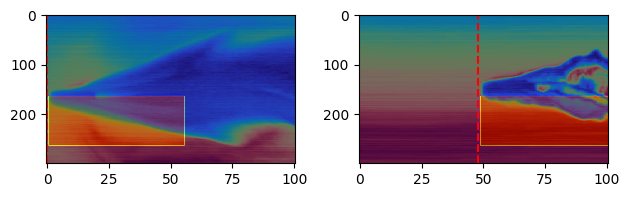

In [31]:
grid_entry_time_first_depth = 0
shift_correction_factor = 1.4
start_shift_pix = 1
length_of_detection = 55
y_bottom_pix = 265#265#300
y_top_pix = 165#150#140#200

first_frame = kymographs[depths_to_extract_pix[1]]
last_frame = kymographs[depths_to_extract_pix[-1]]
total_depth_pixels = abs(depths_to_extract_pix[-1] - depths_to_extract_pix[0])
shift_in_frames_total = int(total_depth_pixels * grid_frames_per_pixel_shift * shift_correction_factor)
grid_entry_time_last_depth = grid_entry_time_first_depth + shift_in_frames_total
print(f"Grid entry time for first depth: {grid_entry_time_first_depth}, Last depth: {grid_entry_time_last_depth}")

# get detection mask for first and last frame 
detection_mask_first = np.zeros_like(first_frame, dtype=int)
detection_range_start_first = grid_entry_time_first_depth + start_shift_pix
detection_range_end_first = detection_range_start_first + length_of_detection
detection_mask_first[y_top_pix:y_bottom_pix, detection_range_start_first:detection_range_end_first] = 1

detection_mask_last = np.zeros_like(last_frame, dtype=int)
detection_range_start_last = grid_entry_time_last_depth + start_shift_pix
detection_range_end_last = detection_range_start_last + length_of_detection
detection_mask_last[y_top_pix:y_bottom_pix, detection_range_start_last:detection_range_end_last] = 1
plt.figure()
plt.subplot(121)
plt.imshow(first_frame, cmap='turbo', aspect=0.2)
plt.imshow(detection_mask_first, cmap='jet', alpha=0.5, aspect=0.2)
plt.axvline(grid_entry_time_first_depth, color='red', linestyle='--', label='Grid Entry Time First Depth')
plt.subplot(122)
plt.imshow(last_frame, cmap='turbo', aspect=0.2)
plt.imshow(detection_mask_last, cmap='jet', alpha=0.5, aspect=0.2)
plt.axvline(grid_entry_time_last_depth, color='red', linestyle='--', label='Grid Entry Time Last Depth')
plt.tight_layout()
plt.show()


In [32]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
time_points_for_each_depth = {}
for i, depth_point in enumerate(depths_to_extract_pix):
    percentage_progress = (i + 1) / len(depths_to_extract_pix) 
    grid_entry = (depth_point - depths_to_extract_pix[0]) *  shift_correction_factor * grid_frames_per_pixel_shift + grid_entry_time_first_depth
    start_time = int(grid_entry + start_shift_pix)
    end_time = int(start_time + length_of_detection)
    time_points_for_each_depth[depth_point] = {
        "grid_entry": grid_entry,
        "start_time": start_time,
        "end_time": end_time,
        "y_bottom_pix" : y_bottom_pix,
        "y_top_pix" : y_top_pix,
    }
    #print(f"y_top_pix for depth {depth_point} is {time_points_for_each_depth[depth_point]['y_top_pix']}")

velocities_measured = {}
velocities_model = {} 
quality_of_fit = {} 
combined_results = {} 
for depth in tqdm(depths_to_extract_pix, desc="Calculating velocities"):
    depth_mm = depths_to_extract[depths_to_extract_pix.index(depth)]  # Convert pixel depth to mm
    kymograph_depth = kymographs[depth]
    velocity_result = get_velocity_from_kymograph(kymograph_depth, \
                                                time_points_for_each_depth[depth], \
                                                apix_lateral, sampling_time, epsilon=2, min_points=2)
    velocities_measured[depth_mm] = velocity_result["velocity_m_per_s"] 
    velocities_model[depth_mm] = np.sqrt(2 * 9.81 * depth_mm * 1e-3)
    #quality_of_fit[depth_mm] = velocity_result["r2_fit"]
    combined_results[depth_mm] = velocity_result


Calculating velocities: 100%|██████████| 129/129 [00:00<00:00, 159.44it/s]

No points found in the mask and edges intersection.


In [33]:
def get_velocity_profile_at_depth(depth_to_plot, apix):
    
    result = combined_results[depth_to_plot]
    #plt.plot(velocity_profile, label=f"Velocity profile at {depth_to_plot} mm")
    #plt.scatter(result["x_points_filtered"], result["y_points_filtered"], marker='o', label=f"Velocity profile at {depth_to_plot} mm")
    x_filtered_test = result["x_points_filtered"]
    y_filtered_test = [x for x in result["y_points_filtered"]]
    if len(x_filtered_test) == 0 or len(y_filtered_test) == 0:
        return None, None, None
    x_unique = np.unique(x_filtered_test)
    y_unique = []
    for x_p in x_unique:
        indices_x = np.where(x_filtered_test == x_p)[0]
        for ix in indices_x:
            all_y_values = y_filtered_test[ix]
        median_y = np.mean(all_y_values)
        y_unique.append(median_y)
    y_unique = np.array(y_unique)
    position = y_unique * apix  # Convert y points to position in meters
    times_array = x_unique * sampling_time  # Convert x points to time in seconds
    if len(y_unique) == 0 or len(x_unique) == 0:
        return None, None, None
    try:
        velocity_test = np.gradient(y_unique, x_unique)  # Calculate velocity from the filtered points
        velocity_test = velocity_test * apix / sampling_time  # Convert to m/s
        return times_array, position, velocity_test
    except Exception as e:
        print(f"Error calculating velocity profile at depth {depth_to_plot}: {e}")
        return None, None, None


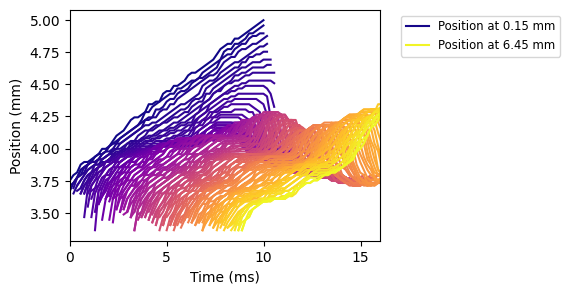

In [34]:
# plot position vs time for all depths as a rainbow plot
colors = sns.color_palette("plasma", len(depths_to_extract))
fig, ax1 = plt.subplots(figsize=(4, 3))
find_shift_amount = True
for i, depth_to_plot in enumerate(depths_to_extract):
    times, positions, velocities = get_velocity_profile_at_depth(depth_to_plot, apix_lateral)
    if times is None or positions is None or velocities is None:
        continue
    if find_shift_amount:
        # Find the shift amount based on the first depth
        shift_amount = times[0] 
        find_shift_amount = False
    times = times - shift_amount  # Shift the time to start from 0
    #times = times_lists[depth_to_plot] * 1000
    #positions = positions_list[depth_to_plot] * 1000
    if i == 1 or i == len(depths_to_extract)-2:
        ax1.plot(times*1000, positions*1000, label=f"Position at {depth_to_plot:.2f} mm", color=colors[i])
    else:
        ax1.plot(times*1000, positions*1000, color=colors[i], alpha=1)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Position (mm)')
ax1.legend(bbox_to_anchor=(1.6, 1), loc='upper right', fontsize='small')
ax1.set_xlim(0, 16)
ax1.set_xticks([0, 5, 10, 15])
#ax1.set_ylim(0, 2.5)
#ax1.set_yticks([0, 0.5, 1])
save_folder = "/home/abharadwaj1/thesis/data_archive/figures_output/5_vitrification/velocity_of_interface"
figsavepath = os.path.join(save_folder, "position_vs_time_all_depths_{}.pdf".format(os.path.basename(video_path).split(".")[0]))

#fig.savefig(figsavepath, bbox_inches='tight', dpi=600)


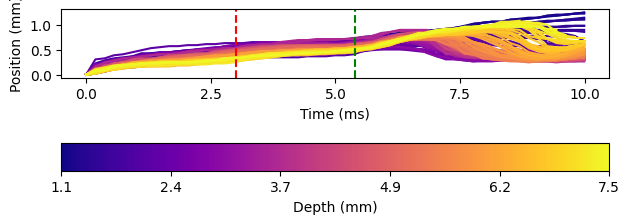

In [42]:
# plot position vs time for all depths as a rainbow plot
colors = sns.color_palette("plasma", len(depths_to_extract))
start_time_for_computing_velocity = 3e-3
end_time_for_computing_velocity = 5.4e-3
figsize_mm = (60, 80)
fig, ax1 = plt.subplots()
all_positions = []
all_times = []
trajectory = {}
for i, depth_to_plot in enumerate(depths_to_extract):
    times, positions, velocities = get_velocity_profile_at_depth(depth_to_plot, apix_lateral)
    

    if times is None or positions is None or velocities is None:
        continue

    times_shifted = times - times[0]  # Shift time to start from 0
    positions_shifted = positions - positions[0]# 0.0033659# 0.00306 #0.003406 #0.003263m for front # Shift position to start from 0
    #times = times_lists[depth_to_plot] * 1000
    #positions = positions_list[depth_to_plot] * 1000
    sorted_times, sorted_positions = largest_nearest_neighbor_segment(times_shifted, positions_shifted, epsilon=4e-3)
    ax1.plot(sorted_times*1000, sorted_positions*1000, color=colors[i])

    all_positions.append(positions)
    all_times.append(times_shifted)
    trajectory[depth_to_plot+1] = { # depth_to_plot is in mm, add 1 to convert to actual depth in mm from midpoint of meniscus
        "times": sorted_times,
        "positions": positions_shifted,
    }

ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Position (mm)')
ax1.axvline(start_time_for_computing_velocity*1000, color='red', linestyle='--', label='Start Time for Velocity')
ax1.axvline(end_time_for_computing_velocity*1000, color='green', linestyle='--', label='End Time for Velocity')
# set aspect ratio to 1:1
ax1.set_aspect('equal')
# add horizontal color bar 
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap="plasma"), ax=ax1, orientation="horizontal")
cbar.set_label('Depth (mm)')
#ticklabels = np.linspace(depths_to_extract[0], depths_to_extract[-1], num=6)
ax1.set_xticks([0, 2.5, 5, 7.5, 10])
ax1.set_yticks([0, 0.5, 1])
cticklabels = [depth+1 for depth in np.linspace(depths_to_extract[0], depths_to_extract[-1], num=6)]
cbar.set_ticklabels(["{:.1f}".format(t) for t in cticklabels])

fig.tight_layout()
fig.savefig(os.path.join(save_folder, "position_vs_time_all_depths_with_velocity_lines_{}_shifted_with_cbar_full_profile_10ms.pdf".format(os.path.basename(video_path).split(".")[0])), bbox_inches='tight', dpi=600)



<Axes: xlabel='Time (ms)', ylabel='Position (mm)'>

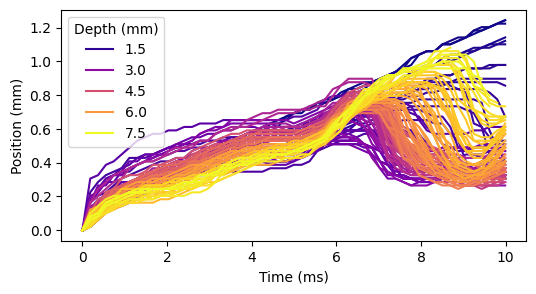

In [43]:
# dump plot data to csv for further analysis
plot_data_folder = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/analyse_cavity_closing/kymograph_analysis"
plot_data_csv = os.path.join(plot_data_folder, "position_vs_time_all_depths_{}.csv".format(os.path.basename(video_path).split(".")[0]))

trajectory_df = pd.DataFrame(columns=["Depth (mm)", "Time (ms)", "Position (mm)"])
for depth, data in trajectory.items():
    times = data["times"]
    positions = data["positions"]
    depth_array = np.full_like(times, depth)
    temp_df = pd.DataFrame({
        "Depth (mm)": depth_array,
        "Time (ms)": times*1000,
        "Position (mm)": positions*1000
    })
    trajectory_df = pd.concat([trajectory_df, temp_df], ignore_index=True)
    
trajectory_df.to_csv(plot_data_csv, index=False)

# Read an plot it again to verify
import seaborn as sns
trajectory_df_read = pd.read_csv(plot_data_csv)
plt.figure(figsize=(6, 3))
sns.lineplot(data=trajectory_df_read, x="Time (ms)", y="Position (mm)", hue="Depth (mm)", palette="plasma")


In [93]:
trajectory_df

,Depth (mm),Time (s),Position (m),Time (ms),Position (mm)
0,1.1,NaN,NaN,0.000000,0.6538
1,1.1,NaN,NaN,0.184980,0.7762
2,1.1,NaN,NaN,0.369959,1.1230
3,1.1,NaN,NaN,0.554939,1.3270
4,1.1,NaN,NaN,0.739919,1.3474
...,...,...,...,...,...
6835,7.5,NaN,NaN,8.509064,1.1230
6836,7.5,NaN,NaN,8.694044,1.1230
6837,7.5,NaN,NaN,8.879023,1.1026
6838,7.5,NaN,NaN,9.064003,1.1026


In [37]:
# # get minimum of all positions 
min_positions_all = min([min(pos) for pos in all_positions])
print(f"Minimum position across all depths: {min_positions_all} m")

Minimum position across all depths: 0.0033659999999999996 m


In [54]:
indices_in_time_range = np.where((times_shifted >= start_time_for_computing_velocity) & (times_shifted <= end_time_for_computing_velocity))[0]
print(f"Indices in time range: {indices_in_time_range}")
times_crop = times_shifted[indices_in_time_range]
print(f"Times in crop: {times_crop}")
velocities = []
quality_of_fit = []
depths_to_plot_mm = []
model_velocities = []   
for i, positions in enumerate(all_positions):
    max_index = max(indices_in_time_range)
    if len(positions) <= max_index:
        print(f"Skipping depth {depths_to_extract[i]} mm due to insufficient data points.")
        continue
    depths_to_plot_mm.append(depths_to_extract[i])
    positions_crop = positions[indices_in_time_range]
    velocity, intercept = np.polyfit(times_crop, positions_crop, 1)
    velocity = velocity
    velocities.append(velocity * -1)
    model_velocity = velocities_model[depths_to_extract[i]]
    # measure quality of fit 
    y_fit = velocity * times_crop + intercept
    ss_res = np.sum((positions_crop - y_fit) ** 2)
    ss_tot = np.sum((positions_crop - np.mean(positions_crop)) ** 2)
    r2_fit = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
    quality_of_fit.append(r2_fit)

velocity_data_df = pd.DataFrame({
    "depth_mm": depths_to_plot_mm,
    "velocity_m_per_s": velocities,
    "quality_of_fit": quality_of_fit,
    "model_velocity_m_per_s": [velocities_model[depth] for depth in depths_to_plot_mm],
})


    




    


Indices in time range: [17 18 19 20 21 22 23 24 25 26 27 28 29]
Times in crop: [0.00314465 0.00332963 0.00351461 0.00369959 0.00388457 0.00406955
 0.00425453 0.00443951 0.00462449 0.00480947 0.00499445 0.00517943
 0.00536441]


In [55]:
# Save the velocity data to a CSV file
velocity_data_csv_path = os.path.join(save_folder, "velocity_data_{}_using_full_profile.csv".format(os.path.basename(video_path).split(".")[0]))
#velocity_data_df.to_csv(velocity_data_csv_path, index=False)

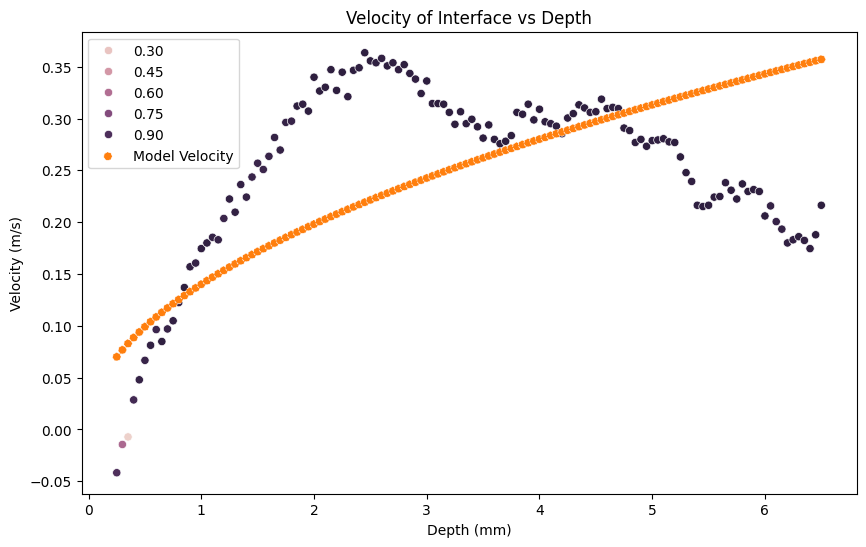

In [56]:
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='depth_mm', y='velocity_m_per_s', data=velocity_data_df, ax=ax1, marker='o', hue="quality_of_fit")
sns.scatterplot(x='depth_mm', y='model_velocity_m_per_s', data=velocity_data_df, ax=ax1, marker='o', linestyle='--', label='Model Velocity')
ax1.set_xlabel('Depth (mm)')
ax1.set_ylabel('Velocity (m/s)')
ax1.set_title('Velocity of Interface vs Depth')
fig.show()

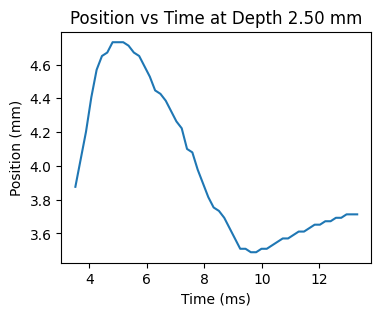

In [58]:
# depth to plot 2.8mm
target_depth_to_plot = 2.5
closest_depth_to_target = min(depths_to_extract, key=lambda x: abs(x - target_depth_to_plot))
times, positions, velocities = get_velocity_profile_at_depth(closest_depth_to_target, apix_lateral)
if times is not None and positions is not None and velocities is not None:
    fig, ax1 = plt.subplots(figsize=(4, 3))
    ax1.plot(times * 1000, positions * 1000, label=f"Position at {depth_to_plot:.2f} mm")
    ax1.set_xlabel('Time (ms)')
    ax1.set_ylabel('Position (mm)')
    ax1.set_title(f'Position vs Time at Depth {closest_depth_to_target:.2f} mm')
    fig.show()

# Save the figure
figsavepath = os.path.join(save_folder, "position_vs_time_at_depth_{}_{}.pdf".format(closest_depth_to_target, os.path.basename(video_path).split(".")[0]))
fig.savefig(figsavepath, bbox_inches='tight', dpi=600)
# save figure data 
fig_data = {
    "times": times.tolist(),
    "positions": positions.tolist(),
    "velocities": velocities.tolist(),
    "depth_mm": closest_depth_to_target,
}
fig_data_path = os.path.join(save_folder, "fig_data_at_depth_{}_{}.json".format(closest_depth_to_target, os.path.basename(video_path).split(".")[0]))
with open(fig_data_path, 'w') as f:
    json.dump(fig_data, f, indent=4)

Text(0, 0.5, 'Velocity (m/s)')

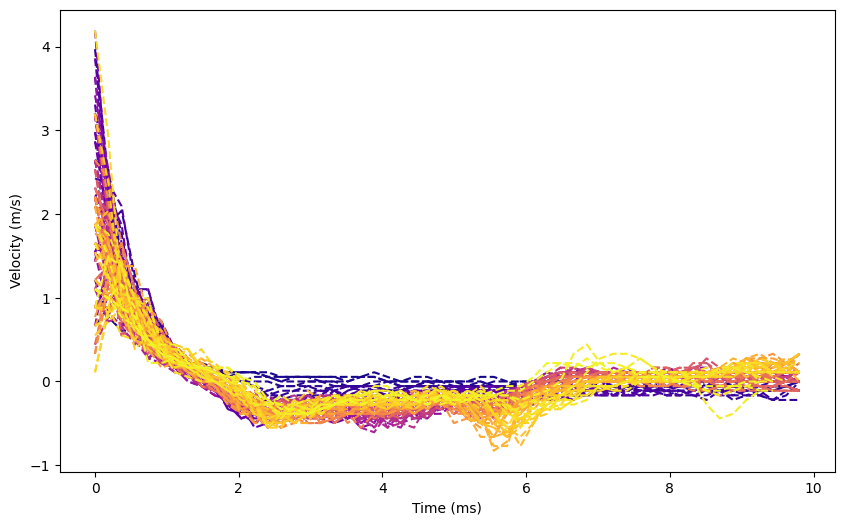

In [60]:
# Plotting the velocity profile using rainbow colors

fig, ax2 = plt.subplots(figsize=(10, 6))
for i, depth_to_plot in enumerate(depths_to_extract):
    times, positions, velocities = get_velocity_profile_at_depth(depth_to_plot, apix_lateral)
    if times is None or positions is None or velocities is None:
        continue
    times_shifted = times - times[0]  # Shift time to start from 0
    ax2.plot(times_shifted*1000, velocities, label=f"Velocity at {depth_to_plot:.2f} mm", color=colors[i], linestyle='--')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Velocity (m/s)')
